# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
anotado = 400
# num_replys_anotados = 150
# num_quotes_anotados = 150
# num_originals_anotados = 150

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1Xg1GIzS0EjcXHU5QeWpz66VgSThqrLvg"
file_class_victor = "1yMqv-9S3-zSZuvwNUZWvfC5x_W_lXVlk"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "contas_suspensas_anotado_caio.csv", quiet=False)
gdown.download(url_2, "contas_suspensas_anotado_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Xg1GIzS0EjcXHU5QeWpz66VgSThqrLvg
To: /content/contas_suspensas_anotado_caio.csv
100%|██████████| 10.1M/10.1M [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1yMqv-9S3-zSZuvwNUZWvfC5x_W_lXVlk
To: /content/contas_suspensas_anotado_victor.csv
100%|██████████| 10.1M/10.1M [00:00<00:00, 21.5MB/s]


'contas_suspensas_anotado_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("contas_suspensas_anotado_caio.csv")
df_victor = pd.read_csv ("contas_suspensas_anotado_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(30665, 6)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(30665, 6)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1.0
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1.0
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1.0
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1.0
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1.0
5,Vocês também estão sentindo que o clima aqui n...,Incrível como comunista gosta de uma censura,1,0.044957,0.955043,1.0
6,Vocês também estão sentindo que o clima aqui n...,"Comemorando censura, é muito tosca msm",1,0.047849,0.952151,1.0
7,"Po, tem um monte de página no twt que propaga ...","Repito: Não é censura qndo vc já foi avisado,...",1,0.048623,0.951377,1.0
8,Vocês também estão sentindo que o clima aqui n...,Gente de esquerda PTRALHAS batendo palmas para...,1,0.048965,0.951035,1.0
9,Vocês também estão sentindo que o clima aqui n...,Só CÚmunistinha caviar e acéfala comemora tama...,1,0.052040,0.947960,1.0


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1.0
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1.0
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1.0
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1.0
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1.0
5,Vocês também estão sentindo que o clima aqui n...,Incrível como comunista gosta de uma censura,1,0.044957,0.955043,1.0
6,Vocês também estão sentindo que o clima aqui n...,"Comemorando censura, é muito tosca msm",1,0.047849,0.952151,1.0
7,"Po, tem um monte de página no twt que propaga ...","Repito: Não é censura qndo vc já foi avisado,...",1,0.048623,0.951377,1.0
8,Vocês também estão sentindo que o clima aqui n...,Gente de esquerda PTRALHAS batendo palmas para...,1,0.048965,0.951035,1.0
9,Vocês também estão sentindo que o clima aqui n...,Só CÚmunistinha caviar e acéfala comemora tama...,1,0.052040,0.947960,1.0


# **Analise Exploratória**



In [10]:
df_remaining = df_caio.iloc[anotado:,:]

In [11]:
# restrigindo por quantidade anotada
df_caio = df_caio.iloc[:anotado,:]
df_caio['Conflict'] = df_caio['Conflict'].astype(int) #convertendo valores para inteiros
df_victor = df_victor.iloc[:anotado,:]
df_victor['Conflict'] = df_victor['Conflict'].astype(int)

In [12]:
#separando por classe

In [13]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1
...,...,...,...,...,...,...
395,A hipocrisia das pessoas que defendem censura ...,Só é censura quando atinge o deles Quando é do...,1,0.068635,0.931365,0
396,Me faltam adjetivos pra classificar a suspensã...,Olha a ingenuidade. Quem é que vai censurar a ...,2,0.068722,0.931278,0
397,"Não se trata de censura, se trata de coibir di...",continua sendo censura,2,0.068751,0.931249,1
398,Dificil admitir q hj é um Grande Dia né minha ...,Vamos ver quem vai comemorar a censura com “Gr...,0,0.068774,0.931226,1


In [14]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1
...,...,...,...,...,...,...
395,A hipocrisia das pessoas que defendem censura ...,Só é censura quando atinge o deles Quando é do...,1,0.068635,0.931365,-1
396,Me faltam adjetivos pra classificar a suspensã...,Olha a ingenuidade. Quem é que vai censurar a ...,2,0.068722,0.931278,1
397,"Não se trata de censura, se trata de coibir di...",continua sendo censura,2,0.068751,0.931249,1
398,Dificil admitir q hj é um Grande Dia né minha ...,Vamos ver quem vai comemorar a censura com “Gr...,0,0.068774,0.931226,1


In [15]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [16]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [17]:
confusion

array([[139.,  22.,   5.],
       [  8., 218.,   0.],
       [  3.,   3.,   2.]])

In [18]:
idx_diff

[10,
 11,
 15,
 26,
 28,
 35,
 47,
 61,
 62,
 66,
 67,
 75,
 80,
 98,
 102,
 116,
 119,
 125,
 131,
 134,
 135,
 137,
 151,
 153,
 178,
 199,
 216,
 230,
 252,
 279,
 288,
 290,
 326,
 329,
 343,
 351,
 366,
 372,
 381,
 395,
 396]

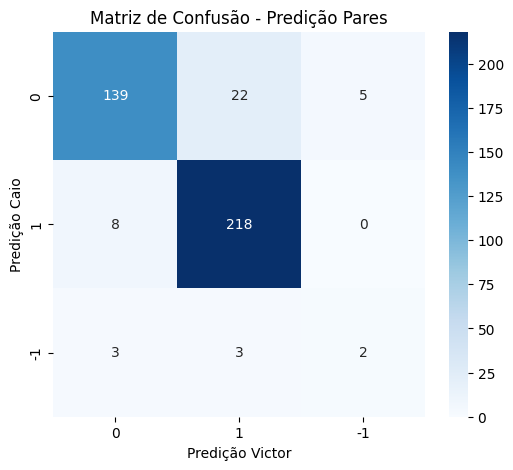

In [19]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [20]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}
mapa_tipo = {0: "Genérico", 1: "Reply", 2: "Quote"}

for i in range(len(idx_diff)):
  print("Tipo: ", mapa_tipo[int(df_caio.loc[idx_diff[i], "Class"])])
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tipo:  Reply
Tweet 1:  Cês tão ligados que isso aqui é nível China de censura, né? Ou vão continuar achando normal e comemorando só porque prejudica a quem vocês não gostam?
Tweet 2:  Quando a censura afeta quem eu não gosto, pode chamar de "justiça".
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tipo:  Reply
Tweet 1:  O que vc pensa de um edital de cultura com censura prévia? A prefeitura de Porto Alegre lançou edital p/ auxílio emergencial cultural q restringe a liberdade de expressão dos artistas, impondo como condição q o assunto não tenha cunho político ou religioso.
Tweet 2:  Te decide, é a favor ou contra a censura.
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tipo:  Reply
Tweet 1:  Errado, se a lei disser que é proibido falar mal do presidente deixa de ser censura? Então não teve censura no regime militar?
Tweet 2:  Acho que estamos em círculos aqui, Andi. Já voltei a me repetir quanto à diferença de censura e crime. Acho que não tenho

In [21]:
#CLASSIFICAÇÕES POR CLASSES CAIO
print("CLASSIFICAÇÕES POR CLASSES CAIO:")
print("contas suspensas:")
print("Conflito:", df_caio[df_caio['Conflict'] == 1].shape[0])
print("Não conflito:", df_caio[df_caio['Conflict'] == 0].shape[0])
print("Indeterminado:", df_caio[df_caio['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES CAIO:
contas suspensas:
Conflito: 226
Não conflito: 166
Indeterminado: 8


In [22]:
#CLASSIFICAÇÕES POR CLASSES VICTOR
print("CLASSIFICAÇÕES POR CLASSES VICTOR:")
print("contas suspensas:")
print("Conflito:", df_victor[df_victor['Conflict'] == 1].shape[0])
print("Não conflito:", df_victor[df_victor['Conflict'] == 0].shape[0])
print("Indeterminado:", df_victor[df_victor['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES VICTOR:
contas suspensas:
Conflito: 243
Não conflito: 150
Indeterminado: 7


In [23]:
#Distribuição de conflitos por classes CAIO

#Separando as classes
reply_caio = df_caio[df_caio['Class'] == 1]
quote_caio = df_caio[df_caio['Class'] == 2]
original_caio = df_caio[df_caio['Class'] == 0]
print("Distribuição de conflitos por classes CAIO:")
print("Replys anotados:", reply_caio.shape[0])
print("Conflitos:", reply_caio[reply_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_caio[reply_caio['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_caio.shape[0])
print("Conflitos:", quote_caio[quote_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_caio[quote_caio['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_caio.shape[0])
print("Conflitos:", original_caio[original_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", original_caio[original_caio['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes CAIO:
Replys anotados: 260
Conflitos: 191
Não conflitos: 67

Quote anotados: 77
Conflitos: 20
Não conflitos: 52

Originals anotados: 63
Conflitos: 15
Não conflitos: 47


In [24]:
#Distribuição de conflitos por classes VICTOR

#Separando as classes
reply_victor = df_victor[df_victor['Class'] == 1]
quote_victor = df_victor[df_victor['Class'] == 2]
original_victor = df_victor[df_victor['Class'] == 0]
print("Distribuição de conflitos por classes VICTOR:")
print("Replys anotados:", reply_victor.shape[0])
print("Conflitos:", reply_victor[reply_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_victor[reply_victor['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_victor.shape[0])
print("Conflitos:", quote_victor[quote_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_victor[quote_victor['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_victor.shape[0])
print("Conflitos:", original_victor[original_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", original_victor[original_victor['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes VICTOR:
Replys anotados: 260
Conflitos: 191
Não conflitos: 65

Quote anotados: 77
Conflitos: 25
Não conflitos: 49

Originals anotados: 63
Conflitos: 27
Não conflitos: 36


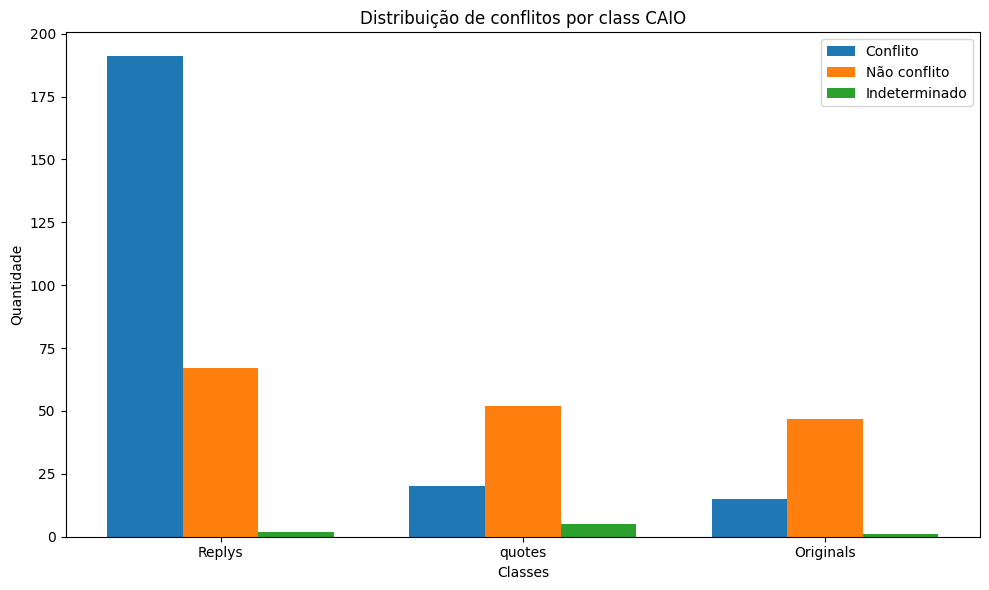

In [25]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_caio[reply_caio['Conflict'] == 1].shape[0],
    quote_caio[quote_caio['Conflict'] == 1].shape[0],
    original_caio[original_caio['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_caio[reply_caio['Conflict'] == 0].shape[0],
    quote_caio[quote_caio['Conflict'] == 0].shape[0],
    original_caio[original_caio['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_caio[reply_caio['Conflict'] == -1].shape[0],
    quote_caio[quote_caio['Conflict'] == -1].shape[0],
    original_caio[original_caio['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class CAIO")

plt.legend()

plt.tight_layout()

plt.show()

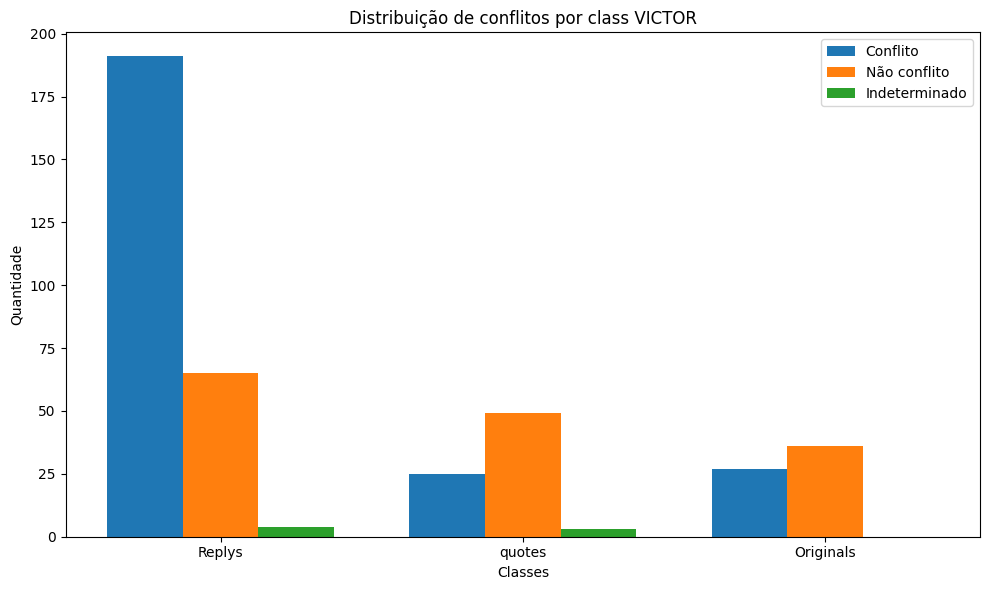

In [26]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_victor[reply_victor['Conflict'] == 1].shape[0],
    quote_victor[quote_victor['Conflict'] == 1].shape[0],
    original_victor[original_victor['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_victor[reply_victor['Conflict'] == 0].shape[0],
    quote_victor[quote_victor['Conflict'] == 0].shape[0],
    original_victor[original_victor['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_victor[reply_victor['Conflict'] == -1].shape[0],
    quote_victor[quote_victor['Conflict'] == -1].shape[0],
    original_victor[original_victor['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class VICTOR")

plt.legend()

plt.tight_layout()

plt.show()

In [27]:
# Previsoes incorretas CAIO:
df_inc_caio = df_caio[(df_caio['P(Conflict)'] > 0.5) & (df_caio['Conflict'] != 1)]
df_inc_caio.shape

(79, 6)

In [28]:
# Previsoes incorretas VICTOR:
df_inc_victor = df_victor[(df_victor['P(Conflict)'] > 0.5) & (df_victor['Conflict'] != 1)]
df_inc_victor.shape

(65, 6)

In [29]:
#Erros por classe de tweet CAIO
print("Erros por classe de tweet:")
print("Replys:", df_inc_caio[df_inc_caio['Class'] == 1].shape[0])
print("Quotes:", df_inc_caio[df_inc_caio['Class'] == 2].shape[0])
print("Originals:", df_inc_caio[df_inc_caio['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 44
Quotes: 15
Originals: 20


In [30]:
#Erros por classe de tweet VICTOR
print("Erros por classe de tweet:")
print("Replys:", df_inc_victor[df_inc_victor['Class'] == 1].shape[0])
print("Quotes:", df_inc_victor[df_inc_victor['Class'] == 2].shape[0])
print("Originals:", df_inc_victor[df_inc_victor['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 42
Quotes: 11
Originals: 12


In [31]:
#Organizando classificações de conflitos de Caio e Victor em um unico DF
df = df_caio.drop('Conflict', axis = 1)
df['Conflict_Caio'] = df_caio['Conflict']
df['Conflict_Victor'] = df_victor['Conflict']

In [32]:
df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_Caio,Conflict_Victor
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1,1
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1,1
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1,1
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1,1
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1,1
...,...,...,...,...,...,...,...
395,A hipocrisia das pessoas que defendem censura ...,Só é censura quando atinge o deles Quando é do...,1,0.068635,0.931365,0,-1
396,Me faltam adjetivos pra classificar a suspensã...,Olha a ingenuidade. Quem é que vai censurar a ...,2,0.068722,0.931278,0,1
397,"Não se trata de censura, se trata de coibir di...",continua sendo censura,2,0.068751,0.931249,1,1
398,Dificil admitir q hj é um Grande Dia né minha ...,Vamos ver quem vai comemorar a censura com “Gr...,0,0.068774,0.931226,1,1


In [33]:
df.to_csv("contas_suspensas_induzido_classificado.csv", index=False, encoding="utf-8")
files.download("contas_suspensas_induzido_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [34]:
div = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div['Conflict'] = np.nan

In [35]:
div.shape

(41, 8)

In [36]:
div

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_caio,Conflict_victor,Conflict
10,Cês tão ligados que isso aqui é nível China de...,"Quando a censura afeta quem eu não gosto, pode...",1,0.055252,0.944748,1,0,NaN
11,O que vc pensa de um edital de cultura com cen...,"Te decide, é a favor ou contra a censura.",1,0.062581,0.937419,0,1,NaN
15,"Errado, se a lei disser que é proibido falar m...","Acho que estamos em círculos aqui, Andi. Já vo...",1,0.073321,0.926680,1,0,NaN
26,"Já é hora, já passou da hora de acabar com ess...",Quando o inquérito investiga só um lado dai é ...,1,0.117276,0.882724,0,1,NaN
28,e as redes sociais ficaram um pouco menos odio...,é censura do bem? é?,2,0.121125,0.878875,0,1,NaN
35,"Para quem defendia a morte do presidente, defe...","Vc discorda DA MENSAGEM, NÃO do mensageiro. Po...",2,0.145344,0.854656,-1,0,NaN
47,Censura contra a esquerda na ditadura militar:...,Na verdade nem se deve comparar a ditadura mil...,1,0.212322,0.787678,1,0,NaN
61,Branca chorando pq uma pessoa falou q preferia...,ah vai tomar no cu,2,0.300295,0.699705,-1,1,NaN
62,Pegue o exemplo do Roberto Jefferson: é um cid...,"O Roberto Jefferson não esta mentindo, ele fal...",1,0.307496,0.692504,0,1,NaN
66,Esse autoritarismo do Ministro Alexandre de Mo...,odiamos censura mas só quando é pros nossos he...,0,0.327721,0.672279,0,1,NaN


In [37]:
div_aborto_final = div.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_aborto_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
10,Cês tão ligados que isso aqui é nível China de...,"Quando a censura afeta quem eu não gosto, pode...",1,0.055252,0.944748,NaN
11,O que vc pensa de um edital de cultura com cen...,"Te decide, é a favor ou contra a censura.",1,0.062581,0.937419,NaN
15,"Errado, se a lei disser que é proibido falar m...","Acho que estamos em círculos aqui, Andi. Já vo...",1,0.073321,0.926680,NaN
26,"Já é hora, já passou da hora de acabar com ess...",Quando o inquérito investiga só um lado dai é ...,1,0.117276,0.882724,NaN
28,e as redes sociais ficaram um pouco menos odio...,é censura do bem? é?,2,0.121125,0.878875,NaN
35,"Para quem defendia a morte do presidente, defe...","Vc discorda DA MENSAGEM, NÃO do mensageiro. Po...",2,0.145344,0.854656,NaN
47,Censura contra a esquerda na ditadura militar:...,Na verdade nem se deve comparar a ditadura mil...,1,0.212322,0.787678,NaN
61,Branca chorando pq uma pessoa falou q preferia...,ah vai tomar no cu,2,0.300295,0.699705,NaN
62,Pegue o exemplo do Roberto Jefferson: é um cid...,"O Roberto Jefferson não esta mentindo, ele fal...",1,0.307496,0.692504,NaN
66,Esse autoritarismo do Ministro Alexandre de Mo...,odiamos censura mas só quando é pros nossos he...,0,0.327721,0.672279,NaN


In [38]:
div_aborto_final.to_csv("divergencias_contas_suspensas_induzido.csv", index=False, encoding="utf-8")
files.download("divergencias_contas_suspensas_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [39]:
conv_aborto = df_caio.drop(index=idx_diff, errors='ignore')
conv_aborto.shape

(359, 6)

In [40]:
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Vocês também estão sentindo que o clima aqui n...,A Sra curte uma censura?,1,0.033065,0.966935,1
1,Vocês também estão sentindo que o clima aqui n...,"Um dia pode ser a sua conta bloqueada, quero v...",1,0.033916,0.966084,1
2,Vocês também estão sentindo que o clima aqui n...,"Pra tu que ama uma ditadura,é um grande dia...",1,0.038408,0.961592,1
3,Vocês também estão sentindo que o clima aqui n...,"Saudade de uma censura, não é minha filha?",1,0.039592,0.960408,1
4,Vocês também estão sentindo que o clima aqui n...,"Todo bom comunista comemora censura, depois sa...",1,0.043954,0.956046,1
...,...,...,...,...,...,...
393,É censura pura e simples . Isso é uma vergonha.,Punição por espalharem mentiras não caracteriz...,1,0.068575,0.931425,1
394,"Proibir, com ordem prévia e geral, que uma pes...",Quando proibiram a Folha de entrevistar o Lula...,1,0.068595,0.931405,1
397,"Não se trata de censura, se trata de coibir di...",continua sendo censura,2,0.068751,0.931249,1
398,Dificil admitir q hj é um Grande Dia né minha ...,Vamos ver quem vai comemorar a censura com “Gr...,0,0.068774,0.931226,1


In [41]:
#juntando anotações do professor (QUANDO ELE ANOTAR)
#adicionando as classificações do professor
# file_class_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
# url = f"https://drive.google.com/uc?id={file_class_prof}"
# gdown.download(url, "class_prof.csv", quiet=False)
# df_class_prof = pd.read_csv ("class_prof.csv")

In [42]:
# df_class_prof

In [43]:
# df_desempate = div.iloc[:len(df_class_prof)-1,:]
# df_desempate

In [44]:
# df_desempate['Conflict_prof'] = df_class_prof['Conflict']
# df_desempate

In [45]:
# def resolver_conflito(row):
#     prof = row['Conflict_prof']
#     caio = row['Conflict_caio']
#     victor = row['Conflict_victor']

#     if prof == caio or prof == victor:
#         return prof
#     else:
#         return -1

# df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [46]:
# df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
# df_desempate

In [47]:
# conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
# conv_aborto

In [48]:
conv_aborto.to_csv("convergencias_contas_suspensas_induzido.csv", index=False, encoding="utf-8")
files.download("convergencias_contas_suspensas_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando dataset dos não anotados**

In [49]:
df_remaining

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
400,"Proibir, com ordem prévia e geral, que uma pes...",E se essa pessoa recebe para destruir reputaçõ...,1,0.068839,0.931161,NaN
401,Alguém avisa para ele que é censura!? Analfabe...,Tá batendo boca comigo até agora jurando que n...,1,0.068840,0.931161,NaN
402,Vocês também estão sentindo que o clima aqui n...,Quem diria que seria a própria oposição través...,2,0.068913,0.931087,NaN
403,Vocês também estão sentindo que o clima aqui n...,Comunista gosta de censura,1,0.068989,0.931011,NaN
404,"por não ter resposta eu sou toda hora, agr rec...",que historia de censura victor na hora q eu di...,1,0.069060,0.930940,NaN
...,...,...,...,...,...,...
30660,Os censurados amanhã podem ser eu e você! #Vo...,Os censurados amanhã podem ser eu e você! #ST...,2,0.995996,0.004004,NaN
30661,#STFVergonhaNacional Alexandre Garcia: Brasil ...,Contas conservadoras sendo suspensas simultane...,0,0.996057,0.003943,NaN
30662,SEXTA-FEIRA DA VERGONHA Alexandre de Moraes ma...,STF VERGONHA NACIONAL #VozParaBernardoKuster,2,0.996067,0.003933,NaN
30663,Os censurados amanhã podem ser eu e você! #Vo...,Cuiďado. Os censurados amanhã podem ser eu e v...,2,0.996080,0.003920,NaN


In [50]:
df_remaining.to_csv("nao_anotados_contas_suspensas_induzido.csv", index=False, encoding="utf-8")
files.download("nao_anotados_contas_suspensas_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>